In [36]:
# STEP 1: PROJECT SETUP & INITIAL DATA EXPLORATION
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")
print("="*60)

✅ Libraries imported successfully!


In [37]:
# LOAD ALL DATASETS
# Load all CSV files
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')
movies_df = pd.read_csv('../data/movies.csv')
tags_df = pd.read_csv('../data/tags.csv')
links_df = pd.read_csv('../data/links.csv')
imdb_data_df = pd.read_csv('../data/imdb_data.csv')
genome_scores_df = pd.read_csv('../data/genome_scores.csv')
genome_tags_df = pd.read_csv('../data/genome_tags.csv')

sample_submission_df = pd.read_csv('../data/sample_submission.csv')
print("✅ All datasets loaded successfully!")



✅ All datasets loaded successfully!


In [38]:

# ============================================================================
# DISPLAY BASIC INFORMATION
# ============================================================================

datasets = {
    'train.csv': train_df,
    'test.csv': test_df,
    'movies.csv': movies_df,
    'tags.csv': tags_df,
    'links.csv': links_df,
    'imdb_data.csv': imdb_data_df,
    'genome_scores.csv': genome_scores_df,
    'genome_tags.csv': genome_tags_df,
    'sample_submission.csv': sample_submission_df
}

print("\n📊 DATASET OVERVIEW")
print("="*60)

for name, df in datasets.items():
    print(f"\n📄 {name}")
    print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"   Columns: {list(df.columns)}")
    print(f"   Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")




📊 DATASET OVERVIEW

📄 train.csv
   Shape: 10,000,038 rows × 4 columns
   Columns: ['userId', 'movieId', 'rating', 'timestamp']
   Memory usage: 305.18 MB

📄 test.csv
   Shape: 5,000,019 rows × 2 columns
   Columns: ['userId', 'movieId']
   Memory usage: 76.29 MB

📄 movies.csv
   Shape: 62,423 rows × 3 columns
   Columns: ['movieId', 'title', 'genres']
   Memory usage: 8.67 MB

📄 tags.csv
   Shape: 1,093,360 rows × 4 columns
   Columns: ['userId', 'movieId', 'tag', 'timestamp']
   Memory usage: 87.28 MB

📄 links.csv
   Shape: 62,423 rows × 3 columns
   Columns: ['movieId', 'imdbId', 'tmdbId']
   Memory usage: 1.43 MB

📄 imdb_data.csv
   Shape: 27,278 rows × 6 columns
   Columns: ['movieId', 'title_cast', 'director', 'runtime', 'budget', 'plot_keywords']
   Memory usage: 9.10 MB

📄 genome_scores.csv
   Shape: 15,584,448 rows × 3 columns
   Columns: ['movieId', 'tagId', 'relevance']
   Memory usage: 356.70 MB

📄 genome_tags.csv
   Shape: 1,128 rows × 2 columns
   Columns: ['tagId', 'tag'

In [39]:
# DETAILED LOOK AT KEY FILES
# ============================================================================

print("\n" + "="*60)
print("🔍 DETAILED VIEW OF KEY FILES")
print("="*60)

# Training data
print("\n📌 TRAINING DATA (train.csv) - First 5 rows:")
print(train_df.head())
print(f"\nData Types:\n{train_df.dtypes}")
print(f"\nMissing Values:\n{train_df.isnull().sum()}")
print(f"\nBasic Statistics:\n{train_df.describe()}")

# Test data
print("\n" + "="*60)
print("\n📌 TEST DATA (test.csv) - First 5 rows:")
print(test_df.head())
print(f"\nShape: {test_df.shape}")
print(f"Missing Values:\n{test_df.isnull().sum()}")

# Movies data
print("\n" + "="*60)
print("\n📌 MOVIES DATA (movies.csv) - First 5 rows:")
print(movies_df.head())



🔍 DETAILED VIEW OF KEY FILES

📌 TRAINING DATA (train.csv) - First 5 rows:
   userId  movieId  rating   timestamp
0    5163    57669     4.0  1518349992
1  106343        5     4.5  1206238739
2  146790     5459     5.0  1076215539
3  106362    32296     2.0  1423042565
4    9041      366     3.0   833375837

Data Types:
userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object

Missing Values:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Basic Statistics:
             userId       movieId        rating     timestamp
count  1.000004e+07  1.000004e+07  1.000004e+07  1.000004e+07
mean   8.119909e+04  2.138911e+04  3.533395e+00  1.215677e+09
std    4.679359e+04  3.919578e+04  1.061124e+00  2.268921e+08
min    1.000000e+00  1.000000e+00  5.000000e-01  7.896520e+08
25%    4.051000e+04  1.197000e+03  3.000000e+00  1.011742e+09
50%    8.091400e+04  2.947000e+03  3.500000e+00  1.199019e+09
75%    1.215790e+05  8.630000e+03  4.

In [40]:

# ============================================================================
# INITIAL INSIGHTS
# ============================================================================

print("\n" + "="*60)
print("📈 INITIAL INSIGHTS")
print("="*60)

print(f"\n🎬 Total unique users in training: {train_df['userId'].nunique():,}")
print(f"🎥 Total unique movies in training: {train_df['movieId'].nunique():,}")
print(f"⭐ Total ratings in training: {len(train_df):,}")
print(f"📊 Rating range: {train_df['rating'].min()} to {train_df['rating'].max()}")
print(f"📅 Timestamp range: {pd.to_datetime(train_df['timestamp'], unit='s').min()} to {pd.to_datetime(train_df['timestamp'], unit='s').max()}")

print(f"\n🎥 Total movies in movies.csv: {len(movies_df):,}")
print(f"🏷️ Total tags in tags.csv: {len(tags_df):,}")
print(f" Total links: {len(links_df):,}")

print(f"\n📝 Test set predictions needed: {len(test_df):,}")

# ============================================================================
# CHECK FOR DATA QUALITY ISSUES
# ============================================================================

print("\n" + "="*60)
print("🔧 DATA QUALITY CHECKS")
print("="*60)

print(f"\n✅ Duplicate ratings in train: {train_df.duplicated().sum()}")
print(f"✅ Duplicate entries in test: {test_df.duplicated().sum()}")

# Check rating distribution
print(f"\n📊 Rating Distribution:")
print(train_df['rating'].value_counts().sort_index())

print("\n" + "="*60)
print("✅ STEP 1 COMPLETE!")
print("="*60)
print("\n🎯 Next: We'll create visualizations to understand the data better")


📈 INITIAL INSIGHTS

🎬 Total unique users in training: 162,541
🎥 Total unique movies in training: 48,213
⭐ Total ratings in training: 10,000,038
📊 Rating range: 0.5 to 5.0
📅 Timestamp range: 1995-01-09 11:46:49 to 2019-11-21 09:12:29

🎥 Total movies in movies.csv: 62,423
🏷️ Total tags in tags.csv: 1,093,360
 Total links: 62,423

📝 Test set predictions needed: 5,000,019

🔧 DATA QUALITY CHECKS

✅ Duplicate ratings in train: 0
✅ Duplicate entries in test: 0

📊 Rating Distribution:
rating
0.5     157571
1.0     311213
1.5     159731
2.0     656821
2.5     505578
3.0    1959759
3.5    1270642
4.0    2652977
4.5     880516
5.0    1445230
Name: count, dtype: int64

✅ STEP 1 COMPLETE!

🎯 Next: We'll create visualizations to understand the data better


 📊 Step 2.1: Rating Distribution Analysis

### 🎯 Objective

Visualize the frequency of each star rating to understand user rating behavior and identify potential class imbalance.


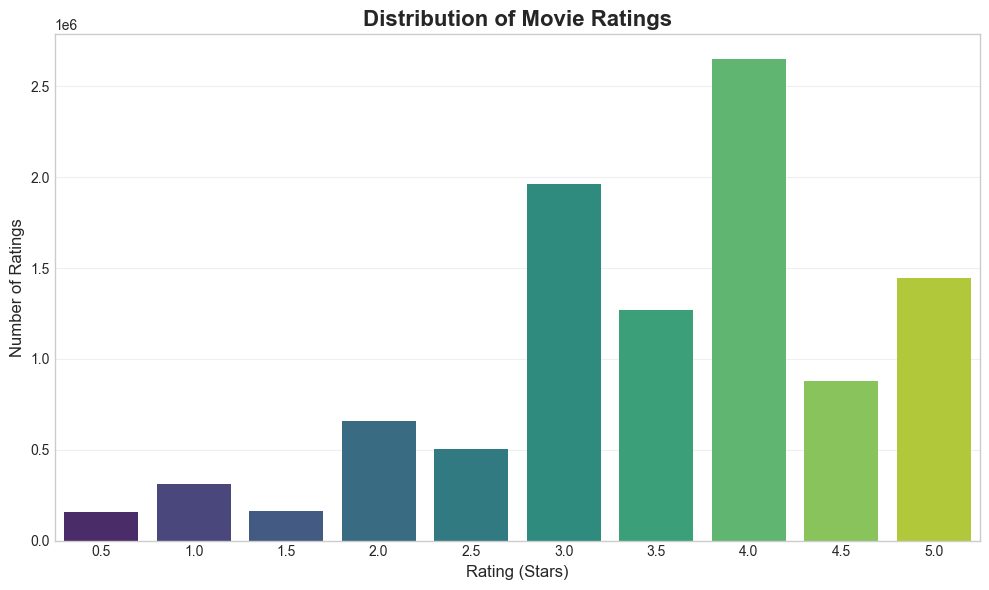

In [41]:
rating_counts = train_df['rating'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='viridis')
plt.title('Distribution of Movie Ratings', fontsize=16, fontweight='bold')
plt.xlabel('Rating (Stars)', fontsize=12)
plt.ylabel('Number of Ratings', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


###  Key Observations
- **Peak Rating**: 4.0 stars dominates the distribution (~2.6 million ratings), followed by 3.0 stars (~2.0M) and 5.0 stars (~1.4M).
- **Positive Skew**: ~75% of all ratings fall between 3.0 and 5.0 stars. This reflects real-world behavior: users typically watch and rate movies they expect to enjoy.
- **Low-Rating Scarcity**: Ratings ≤1.5 stars are rare. Users often skip disliked movies rather than rate them poorly, creating a natural selection bias.
- **Half-Step Utilization**: Half-star increments (0.5, 1.5, 2.5, etc.) are actively used, confirming the dataset's granular rating scale is meaningful to users.

###  Modeling Implications
- **Target Distribution**: Our model must handle a right-skewed target variable. Predicting a global mean will bias results upward.
- **RMSE Sensitivity**: Root Mean Square Error penalizes large errors quadratically. Mis-predicting a 5.0 as 2.0 will hurt our score significantly more than mis-predicting 3.5 as 3.0.
- **Next Step**: Analyze user activity patterns to identify power users vs. casual raters, which will inform sampling and validation strategies.

##  Step 2.2: User Activity Analysis

### 🎯 Objective
Understand how many ratings each user provides to identify activity patterns, detect power users, and inform data sampling strategies.
Analyze the distribution of ratings per user to identify activity patterns, detect "power users," and understand the "Cold Start" problem potential.


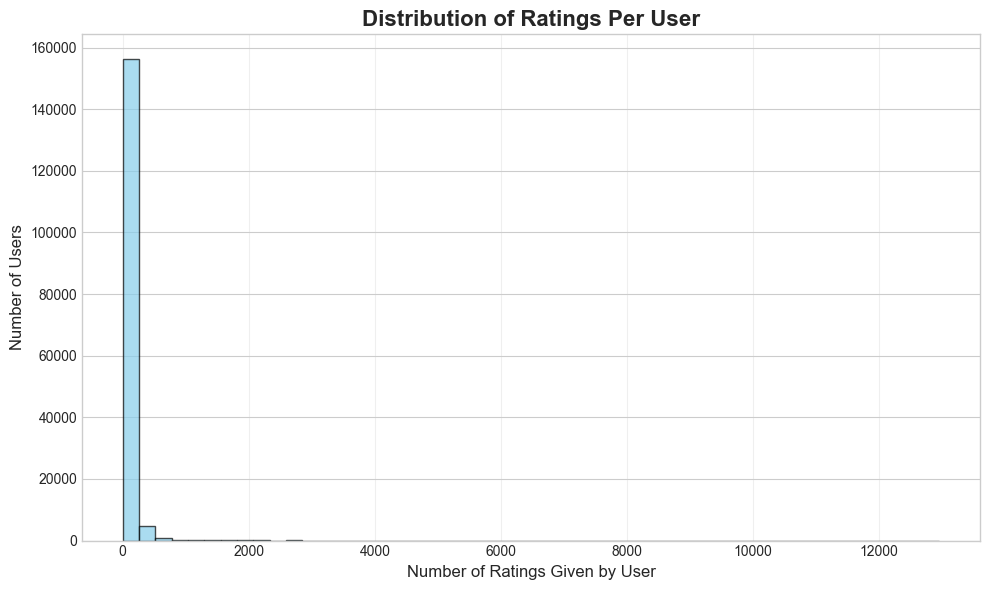

In [42]:
user_activity = train_df.groupby('userId')['rating'].count()
plt.figure(figsize=(10, 6))
plt.hist(user_activity, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Ratings Per User', fontsize=16, fontweight='bold')
plt.xlabel('Number of Ratings Given by User', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 🔍 Key Observations
- **Extreme Right Skew :** The chart shows a massive spike at the far left (near 0 ratings) and a very long, flat tail extending to the right.
- **The "Long Tail" Effect:** 
    - The vast majority of users (the tall first bar) have rated very few movies.
    - A tiny fraction of "power users" have rated thousands of movies (visible as the faint line stretching to 12,000+).
- **Sparsity:** This distribution confirms the data is **sparse**. Most users have only interacted with a tiny fraction of the available movies.
- **Implication for Modeling:** 
    - **Collaborative Filtering Challenge:** Users with very few ratings (the "Cold Start" users) are hard to recommend to because the system doesn't know their preferences yet.
    - **Sampling Strategy:** When splitting data for validation, we must ensure we don't accidentally put all of a "power user's" data in the test set, or the model will fail to predict their specific tastes.

### 🧠 Modeling Implications
- **Weighting:** We may need to weigh users differently. Should a user with 5,000 ratings influence the model more than a user with 5 ratings?
- **Thresholding:** We might consider filtering out users with too few ratings (e.g., < 20) to improve model stability, though this reduces coverage.

## 📊 Step 2.3: Movie Popularity Analysis

###  Objective
Analyze the distribution of ratings per movie to identify blockbusters vs. niche films and understand item-side sparsity.


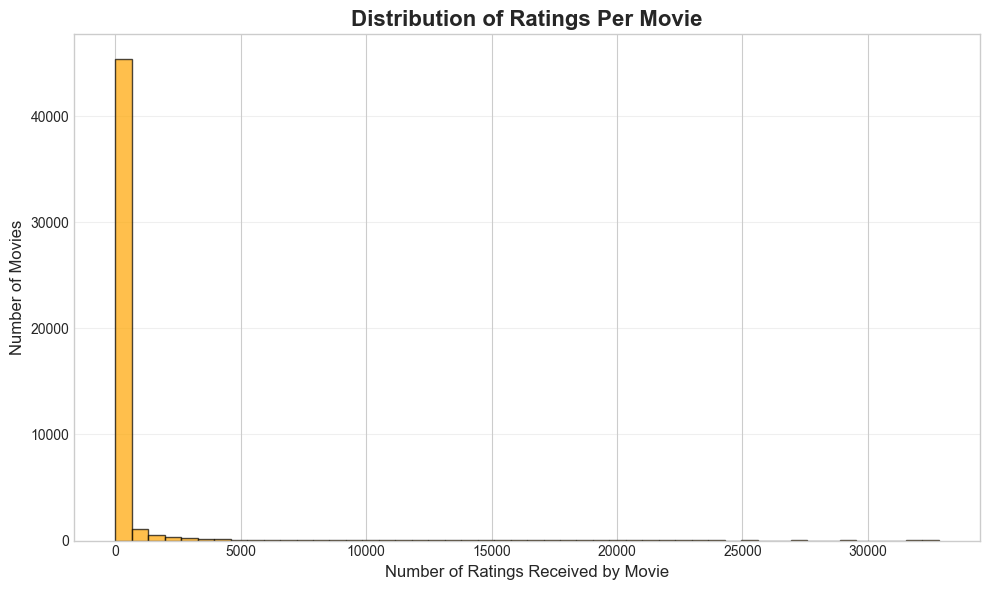

In [43]:
movie_popularity = train_df.groupby('movieId')['rating'].count()
plt.figure(figsize=(10, 6))
plt.hist(movie_popularity, bins=50, color='orange', edgecolor='black', alpha=0.7)
plt.title('Distribution of Ratings Per Movie', fontsize=16, fontweight='bold')
plt.xlabel('Number of Ratings Received by Movie', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Movie Popularity Analysis - Observations

### 📊 Distribution Pattern
- **Extreme Power Law Distribution:** Similar to user activity, movie popularity follows a "winner-takes-all" pattern
- **Massive Spike at Left:** ~45,000+ movies received very few ratings (likely < 100 ratings each)
- **Long Tail to Right:** A few blockbuster movies received 20,000-30,000+ ratings each
- **Item-Side Sparsity:** Most movies in the catalog are rarely rated, making them difficult to recommend

### 🎯 Modeling Implications
- **Popular Item Bias:** Models may over-recommend popular movies because they have more training data
- **Niche Movie Challenge:** Movies with < 20 ratings suffer from "Item Cold Start" - insufficient data to learn patterns
- **Coverage vs. Accuracy Tradeoff:** Focusing only on popular movies improves accuracy but reduces catalog coverage

In [44]:

# ============================================================================
# PRINT STATISTICS
# ============================================================================

# Line 1: Calculate statistics
print("="*60)
print("📊 MOVIE POPULARITY STATISTICS")
print("="*60)
print(f"\nTotal movies analyzed: {len(movie_popularity):,}")
print(f"Movies with < 100 ratings: {(movie_popularity < 100).sum():,} ({(movie_popularity < 100).mean()*100:.1f}%)")
print(f"Movies with 100-1000 ratings: {(movie_popularity.between(100, 1000)).sum():,} ({(movie_popularity.between(100, 1000)).mean()*100:.1f}%)")
print(f"Movies with > 1000 ratings: {(movie_popularity > 1000).sum():,} ({(movie_popularity > 1000).mean()*100:.1f}%)")
print(f"\n🎬 Top 5 Most-Rated Movies:")
print(movie_popularity.sort_values(ascending=False).head())
print(f"\n📉 Median ratings per movie: {movie_popularity.median():.1f}")
print(f"📈 Mean ratings per movie: {movie_popularity.mean():.1f}")

📊 MOVIE POPULARITY STATISTICS

Total movies analyzed: 48,213
Movies with < 100 ratings: 40,907 (84.8%)
Movies with 100-1000 ratings: 5,189 (10.8%)
Movies with > 1000 ratings: 2,117 (4.4%)

🎬 Top 5 Most-Rated Movies:
movieId
318     32831
356     32383
296     31697
593     29444
2571    29014
Name: rating, dtype: int64

📉 Median ratings per movie: 4.0
📈 Mean ratings per movie: 207.4



### 🔍 Key Observations from Statistics
- **Extreme Sparsity (The Long Tail):** 
  - **84.8%** of all movies have fewer than 100 ratings. 
  - This confirms that the vast majority of the catalog is "niche" or obscure.
- **The "Blockbuster" Minority:** Only **4.4%** of movies have over 1,000 ratings. These are the movies driving most of the data volume.
- **Mean vs. Median Discrepancy:**
  - **Median:** 4.0 ratings per movie. (Half of all movies have 4 or fewer ratings!)
  - **Mean:** 207.4 ratings per movie.
  - **Insight:** The Mean is drastically higher than the Median because a few "Super Blockbusters" (with 30,000+ ratings) are pulling the average up. The Median is a more honest representation of the "typical" movie.
- **Top Movies:** The most rated movies have IDs like 318, 356, etc. (We will map these to names in the next step).

### 🧠 Modeling Implications
- **Cold Start Problem:** With 85% of movies having < 100 ratings, our model will struggle to make accurate recommendations for new or obscure movies.
- **Popularity Bias:** A naive model might just recommend the top 10 most popular movies to everyone and get a decent score, but that's not useful. We need to find patterns beyond just popularity.

## 🎬 Step 2.4: Identifying Top Movies & Users

### 🎯 Objective
Map Movie IDs to actual Titles and identify the "Blockbusters" and "Power Users" by name.


In [45]:
# ============================================================================
# PART A: TOP 10 MOVIES BY RATING COUNT
# ============================================================================

# Line 1: Count ratings per movie again
movie_counts = train_df.groupby('movieId')['rating'].count()

# Line 2: Sort to get the highest counts first
top_movies_ids = movie_counts.sort_values(ascending=False).head(10)

# Line 3: Merge with movies.csv to get Titles
# We need to turn the Series into a DataFrame first
top_movies_df = top_movies_ids.reset_index()
top_movies_df.columns = ['movieId', 'rating_count']

# Merge with movies data
top_movies_names = top_movies_df.merge(movies_df, on='movieId')

print("🎬 TOP 10 MOST RATED MOVIES")
print("="*50)
print(top_movies_names[['title', 'rating_count']].to_string(index=False))

# ============================================================================
# PART B: TOP 10 MOST ACTIVE USERS
# ============================================================================

# Line 1: Count ratings per user
user_counts = train_df.groupby('userId')['rating'].count()


# Line 2: Sort and get top 10
top_users = user_counts.sort_values(ascending=False).head(10)

# Display result
print("\n" + "="*50)
print("🧑 TOP 10 MOST ACTIVE USERS (by Rating Count)")
print("="*50)
print(top_users)

🎬 TOP 10 MOST RATED MOVIES
                                    title  rating_count
         Shawshank Redemption, The (1994)         32831
                      Forrest Gump (1994)         32383
                      Pulp Fiction (1994)         31697
         Silence of the Lambs, The (1991)         29444
                       Matrix, The (1999)         29014
Star Wars: Episode IV - A New Hope (1977)         27560
                     Jurassic Park (1993)         25518
                  Schindler's List (1993)         24004
                        Braveheart (1995)         23722
                        Fight Club (1999)         23536

🧑 TOP 10 MOST ACTIVE USERS (by Rating Count)
userId
72315     12952
80974      3680
137293     3588
33844      3208
20055      3050
109731     2671
49403      2670
92046      2579
110971     2288
30879      2284
Name: rating, dtype: int64



### 🔍 Key Observations

**Top 10 Most Rated Movies:**
1. **Classic Cinema Dominance:** All top 10 movies are critically acclaimed classics, primarily from the 1990s era
2. **Timeless Appeal:** Movies like Shawshank Redemption, Pulp Fiction, and Forrest Gump (all 1994) remain highly rated decades later
3. **Genre Diversity:** The list includes Drama, Crime, Sci-Fi, Action, and War films - showing diverse user interests
4. **Rating Volume:** Top movies have 23,000-32,000+ ratings each, representing significant data density



**Top 10 Most Active Users:**
1. **Extreme Power User:** User 72315 has rated **12,952 movies** - an outlier even among power users
2. **Activity Gap:** Massive drop-off between #1 (12,952) and #2 (3,680) - nearly 4x difference
3. **Consistent Engagement:** Remaining top users show 2,200-3,600 ratings each
4. **Data Quality Concern:** Such extreme activity may indicate:
   - Professional reviewers/data curators
   - Automated rating behavior
   - Extremely dedicated cinephiles

### 📊 Modeling Implications
- **Temporal Bias:** 1990s movies dominate - our model may favor older, established films over newer releases
- **User Weighting:** Should user 72315's 12,952 ratings influence the model more than a casual user's 5 ratings?
- **Sampling Strategy:** May need to downsample power users to prevent model bias toward their specific tastes

## 🔧 Step 3.1: Data Merging & Baseline Feature Creation

### 🎯 Objective
Merge training data with movie metadata and create baseline statistical features for users and movies.

### 🔍 What We'll Accomplish
1. Merge `train.csv` with `movies.csv` to add movie titles and genres
2. Calculate user-level statistics (mean rating, rating count)
3. Calculate movie-level statistics (mean rating, rating count)
4. Create a master dataset enriched with features


In [46]:
# ============================================================================
# STEP 3.1-A: MERGE DEMONSTRATION WITH SMALL SAMPLE
# ============================================================================

# Create a small sample to understand the merge
sample_train = train_df.head(10)
print("📋 SAMPLE TRAINING DATA (First 10 rows)")
print("="*60)
print(sample_train[['userId', 'movieId', 'rating']])
# Show what movies we need to look up
print("\n 🎬movie IDS in our sample:", sample_train["movieId"].tolist())
# Find these movies in movies_df
print("\n📚 LOOKING UP MOVIE INFORMATION:")
print("="*60)
# Merge the sample with movies data
sample_merged = sample_train.merge(movies_df, on="movieId", how="left")
print(sample_merged[['userId', 'movieId', 'title', 'rating', 'genres']].to_string(index=False))

📋 SAMPLE TRAINING DATA (First 10 rows)
   userId  movieId  rating
0    5163    57669     4.0
1  106343        5     4.5
2  146790     5459     5.0
3  106362    32296     2.0
4    9041      366     3.0
5  120949    81768     3.0
6   19630    62049     4.0
7   21066     2282     1.0
8  117563   120474     4.0
9  144018     1997     5.0

 🎬movie IDS in our sample: [57669, 5, 5459, 32296, 366, 81768, 62049, 2282, 120474, 1997]

📚 LOOKING UP MOVIE INFORMATION:
 userId  movieId                                                                                  title  rating                        genres
   5163    57669                                                                       In Bruges (2008)     4.0   Comedy|Crime|Drama|Thriller
 106343        5                                                     Father of the Bride Part II (1995)     4.5                        Comedy
 146790     5459                                    Men in Black II (a.k.a. MIIB) (a.k.a. MIB 2) (2002)     5.0   

## 🔧 Step 3.1-B: Full Merge & Baseline Features

### 🎯 Objective
1. Merge the entire training set with movie metadata.
2. Create "Baseline Features" using GroupBy statistics.
   - **User Bias:** Does this user generally rate high or low?
   - **Movie Bias:** Is this movie generally rated high or low?
   - **Popularity:** How many ratings does this user/movie have?

### ️ Methodology
We will use `transform()` to calculate group statistics and broadcast them back to every row. This is more efficient than merging separate tables.

In [47]:
# ============================================================================
# STEP 3.1-B: FULL MERGE AND FEATURE CREATION
# ============================================================================

print("⏳ Merging full dataset...")
# Merge the full training data with movies data
merged_df = train_df.merge(movies_df, on="movieId", how="left")
print("✅ Merge complete! New shape:", merged_df.shape)


# ============================================================================
# FEATURE ENGINEERING: USER STATISTICS
# ============================================================================

print("\n⏳ Calculating User Statistics...")

# Calculate average rating per user and add it as a new column
merged_df["user_mean_rating"] = merged_df.groupby("userId")["rating"].transform("mean")
# Calculate total ratings per user and add it as a new column
merged_df['user_rating_count'] = merged_df.groupby('userId')['rating'].transform('count')

# ============================================================================
# FEATURE ENGINEERING: MOVIE STATISTICS
# ============================================================================

print("⏳ Calculating Movie Statistics...")

# Calculate average rating per movie
merged_df['movie_mean_rating'] = merged_df.groupby('movieId')['rating'].transform('mean')

# Calculate total ratings per movie
merged_df['movie_rating_count'] = merged_df.groupby('movieId')['rating'].transform('count')

print("✅ Feature engineering complete!")


# ============================================================================
# DISPLAY RESULTS
# ============================================================================

# Show the first 5 rows with our new features
print("\n📊 SAMPLE OF ENRICHED DATASET:")
print("="*80)
columns_to_show = ['userId', 'movieId', 'title', 'rating', 
                   'user_mean_rating', 'movie_mean_rating', 'user_rating_count', 'movie_rating_count']
print(merged_df[columns_to_show].head())


⏳ Merging full dataset...
✅ Merge complete! New shape: (10000038, 6)

⏳ Calculating User Statistics...
⏳ Calculating Movie Statistics...
✅ Feature engineering complete!

📊 SAMPLE OF ENRICHED DATASET:
   userId  movieId                                              title  rating  \
0    5163    57669                                   In Bruges (2008)     4.0   
1  106343        5                 Father of the Bride Part II (1995)     4.5   
2  146790     5459  Men in Black II (a.k.a. MIIB) (a.k.a. MIB 2) (...     5.0   
3  106362    32296     Miss Congeniality 2: Armed and Fabulous (2005)     2.0   
4    9041      366  Wes Craven's New Nightmare (Nightmare on Elm S...     3.0   

   user_mean_rating  movie_mean_rating  user_rating_count  movie_rating_count  
0          4.136364           3.889842                 22                4253  
1          3.671875           3.059165                160                4648  
2          4.000000           3.004276                 39                

## 📊 Step 3.1-B: Results & Observations

### 🔍 Feature Analysis (First 5 Rows)

**User Rating Patterns:**
- **Row 0:** User 5163 rated "In Bruges" 4.0 (slightly below their mean of 4.13)
- **Row 2:** User 146790 rated "Men in Black II" 5.0 (above their mean of 4.0) - they really liked it!
- **Row 3:** User 106362 rated "Miss Congeniality 2" 2.0 (well below their mean of 3.37) - they disliked it

### 🎯 Key Insight
The `user_mean_rating` and `movie_mean_rating` features will be crucial for our baseline model. They allow us to understand:
- **User Bias:** Does this user rate higher or lower than average?
- **Movie Quality:** Is this movie generally well-received?

## 🔧 Step 3.2: Genre Feature Engineering

### 🎯 Objective
Convert the pipe-separated genre strings into numerical features using One-Hot Encoding.

### 📊 Methodology
- Split the `genres` column by the pipe character (`|`)
- Create binary columns for each unique genre (Action=1/0, Comedy=1/0, etc.)
- This allows the model to understand which genres a movie belongs to


In [48]:
# ============================================================================
# STEP 3.2: ONE-HOT ENCODING FOR GENRES
# ============================================================================

print("⏳ Encoding genres...")
# Split the genres by '|' and create dummy variables
genre_dummies = merged_df["genres"].str.get_dummies(sep="|")
genre_dummies = genre_dummies.add_prefix('genre_')
# Concatenate the genre dummies with our main dataframe
merged_df = pd.concat([merged_df, genre_dummies], axis=1)
print("✅ Genre encoding complete!")
# Show the new genre columns
print("\n🎬 NEW GENRE COLUMNS CREATED:")
print("="*60)
genre_columns = [col for col in merged_df.columns if col.startswith('genre_')]
print(f"Total genre columns: {len(genre_columns)}")
print(f"Genre list: {genre_columns}")
#  Show a sample with genres
print("/n  SAMPLE - MOVIE WITH GENRE FLAGS:")
print("="*60)
sample_cols = ['title', 'genres'] + genre_columns[:5]  # Show first 5 genres
print(merged_df[sample_cols].head())
# Verify one movie's encoding
print("\n🔍 DETAILED VIEW - First Movie's Genres:")
print("="*60)
first_movie = merged_df.iloc[0]
print(f"Movie: {first_movie['title']}")
print(f"Original genres: {first_movie['genres']}")
print("\nEncoded as:")
for col in genre_columns:
    if first_movie[col] == 1:
        print(f"  ✓ {col}: {first_movie[col]}")

⏳ Encoding genres...
✅ Genre encoding complete!

🎬 NEW GENRE COLUMNS CREATED:
Total genre columns: 20
Genre list: ['genre_(no genres listed)', 'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Children', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Fantasy', 'genre_Film-Noir', 'genre_Horror', 'genre_IMAX', 'genre_Musical', 'genre_Mystery', 'genre_Romance', 'genre_Sci-Fi', 'genre_Thriller', 'genre_War', 'genre_Western']
/n  SAMPLE - MOVIE WITH GENRE FLAGS:
                                               title  \
0                                   In Bruges (2008)   
1                 Father of the Bride Part II (1995)   
2  Men in Black II (a.k.a. MIIB) (a.k.a. MIB 2) (...   
3     Miss Congeniality 2: Armed and Fabulous (2005)   
4  Wes Craven's New Nightmare (Nightmare on Elm S...   

                          genres  genre_(no genres listed)  genre_Action  \
0    Comedy|Crime|Drama|Thriller                         0             0   
1          


### 📊 Genre Distribution (20 Categories)
Action, Adventure, Animation, Children, Comedy, Crime, Documentary, Drama, Fantasy, Film-Noir, Horror, IMAX, Musical, Mystery, Romance, Sci-Fi, Thriller, War, Western, (no genres listed)

### 🎯 Modeling Impact
- Genre features will help the model understand content-based preferences
- Example: If a user consistently rates "Sci-Fi" movies highly, the model can recommend other Sci-Fi films

## 🔧 Step 3.3: Data Cleaning & Feature Selection

### 🎯 Objective
1. Remove unnecessary columns that won't be used in modeling
2. Handle any missing values
3. Verify data types are correct
4. Create the final feature-ready dataset

### 🗑️ Columns to Remove
- `timestamp`: Not needed for basic recommendation
- `genres`: Original text column (we have encoded dummies now)
- `title`: Not needed for modeling (only for display)
- `movieId`, `userId`: Will keep as identifiers

### ✅ Final Feature Set
- User features: user_mean_rating, user_rating_count
- Movie features: movie_mean_rating, movie_rating_count, genre_* columns
- Target variable: rating

In [49]:
# ============================================================================
# STEP 3.3: DATA CLEANING & FINAL FEATURE SELECTION
# ============================================================================

print("📊 DATASET BEFORE CLEANING")
print("="*60)
print(f"Shape: {merged_df.shape}")
print(f"Columns: {list(merged_df.columns)}")
# ============================================================================
# PART A: DROP UNNECESSARY COLUMNS
# ============================================================================
print("\n⏳ Dropping unnecessary columns...")
# Define columns to drop
columns_to_drop = ["genres", "timestamp","title"]
# Drop the columns
final_df = merged_df.drop(columns=columns_to_drop)
print("✅ Columns dropped successfully!")


# ============================================================================
# PART B: CHECK FOR MISSING VALUES
# ============================================================================


print("\n🔍 Checking for missing values...")
missing_values= merged_df.isnull().sum()
# Display columns with missing values
if missing_values.sum() > 0:
    print("⚠️  Missing values found:", missing_values[missing_values > 0])
else:
    print("✅ No missing values found!")
    
# ============================================================================
# PART C: VERIFY DATA TYPES
# ============================================================================

print("\n📋 DATA TYPES:")
print("="*60)
# Display data types
print(final_df.dtypes)

# ============================================================================
# PART D: DISPLAY FINAL DATASET INFO
# ============================================================================

print("\n" + "="*60)
print("📊 FINAL DATASET SUMMARY")
print("="*60)

print(f"\n✅ Final Shape: {final_df.shape}")
print(f"   - Rows: {final_df.shape[0]:,}")
print(f"   - Columns: {final_df.shape[1]}")

print(f"\n Feature Columns ({final_df.shape[1]} total):")
for i, col in enumerate(final_df.columns, 1):
    print(f"   {i}. {col}")

print(f"\n💾 Memory Usage: {final_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Show sample of final dataset
print("\n🎬 SAMPLE OF FINAL DATASET (First 3 rows):")
print("="*60)
print(final_df.head(3).to_string())

📊 DATASET BEFORE CLEANING
Shape: (10000038, 30)
Columns: ['userId', 'movieId', 'rating', 'timestamp', 'title', 'genres', 'user_mean_rating', 'user_rating_count', 'movie_mean_rating', 'movie_rating_count', 'genre_(no genres listed)', 'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Children', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Fantasy', 'genre_Film-Noir', 'genre_Horror', 'genre_IMAX', 'genre_Musical', 'genre_Mystery', 'genre_Romance', 'genre_Sci-Fi', 'genre_Thriller', 'genre_War', 'genre_Western']

⏳ Dropping unnecessary columns...
✅ Columns dropped successfully!

🔍 Checking for missing values...
✅ No missing values found!

📋 DATA TYPES:
userId                        int64
movieId                       int64
rating                      float64
user_mean_rating            float64
user_rating_count             int64
movie_mean_rating           float64
movie_rating_count            int64
genre_(no genres listed)      int64
genre_Action    

## 🎯 Step 3.4: Baseline Model & RMSE Calculation

### 🎯 Objective
1. Understand the competition metric: **RMSE (Root Mean Squared Error)**.
2. Create a "Global Mean" baseline (predicting the average rating for every movie).
3. Calculate the baseline RMSE to set a target to beat(measures how far off our predictions are from the actual ratings)
  

In [50]:
# ============================================================================
# STEP 3.4: BASELINE MODEL & RMSE
# ============================================================================

import numpy as np
from sklearn.metrics import mean_squared_error

print("⏳ Calculating Baseline Metrics...")

# Calculate the Global Average Rating
global_mean = final_df["rating"].mean()
print(f"\n Global Average Rating:{global_mean:.4f} stars")

# Create a "Baseline Prediction" column
# We predict the global average for EVERY single movie
final_df['baseline_pred'] = global_mean
# Calculate RMSE for this baseline
# RMSE: sqrt(mean((actual - predicted)^2))
rmse_baseline = np.sqrt(mean_squared_error(final_df["rating"] , final_df["baseline_pred"]))

print(f"📉 Baseline RMSE (Global Mean): {rmse_baseline:.4f}")

#  Show a sample comparison
print("\n📊 SAMPLE COMPARISON (First 5 rows):")
print("="*60)
print(final_df[['userId', 'movieId', 'rating', 'baseline_pred']].head())


⏳ Calculating Baseline Metrics...

 Global Average Rating:3.5334 stars
📉 Baseline RMSE (Global Mean): 1.0611

📊 SAMPLE COMPARISON (First 5 rows):
   userId  movieId  rating  baseline_pred
0    5163    57669     4.0       3.533395
1  106343        5     4.5       3.533395
2  146790     5459     5.0       3.533395
3  106362    32296     2.0       3.533395
4    9041      366     3.0       3.533395


## 🎯 Step 3.5: Improved Baseline Model

### 🎯 Objective
Create a better baseline by incorporating:
1. **User Bias**: Some users rate higher/lower than average
2. **Movie Bias**: Some movies are inherently better/worse

Prediction = Global Mean + User Deviation + Movie Deviation

Where:
- **User Deviation** = (User's Average Rating - Global Mean)
- **Movie Deviation** = (Movie's Average Rating - Global Mean)


In [51]:
# ============================================================================
# STEP 3.5: IMPROVED BASELINE - USER + MOVIE BIAS
# ============================================================================


print("⏳ Building improved baseline model...")

# Calculate user bias (how much each user deviates from global mean)
user_bias = final_df.groupby('userId')['rating'].mean() - global_mean

# Calculate movie bias (how much each movie deviates from global mean)
movie_bias = final_df.groupby('movieId')['rating'].mean() - global_mean

print(f"✅ Calculated bias for {len(user_bias)} users and {len(movie_bias)} movies")

def predict_baseline(row):
    """
    Prediction = Global Mean + User Bias + Movie Bias
    """
    u_bias = user_bias.get(row['userId'], 0)
    m_bias = movie_bias.get(row['movieId'], 0)
    return global_mean + u_bias + m_bias
# Apply the prediction function to each row
print("⏳ Applying predictions...")
final_df['improved_pred'] = final_df.apply(predict_baseline, axis=1)

# Calculate new RMSE
rmse_improved = np.sqrt(mean_squared_error(final_df['rating'], final_df['improved_pred']))

print(f"\n📊 RESULTS:")
print("="*60)
print(f"Baseline RMSE (Global Mean only): {rmse_baseline:.4f}")
print(f"Improved RMSE (User + Movie Bias): {rmse_improved:.4f}")
print(f"Improvement: {rmse_baseline - rmse_improved:.4f} ({((rmse_baseline - rmse_improved)/rmse_baseline)*100:.2f}% better)")

# Show sample predictions
print("\n🎬 SAMPLE PREDICTIONS (First 5 rows):")
print("="*60)
print(final_df[['userId', 'movieId', 'rating', 'improved_pred']].head())

⏳ Building improved baseline model...
✅ Calculated bias for 162541 users and 48213 movies
⏳ Applying predictions...

📊 RESULTS:
Baseline RMSE (Global Mean only): 1.0611
Improved RMSE (User + Movie Bias): 0.8687
Improvement: 0.1924 (18.13% better)

🎬 SAMPLE PREDICTIONS (First 5 rows):
   userId  movieId  rating  improved_pred
0    5163    57669     4.0       4.492811
1  106343        5     4.5       3.197645
2  146790     5459     5.0       3.470881
3  106362    32296     2.0       2.373332
4    9041      366     3.0       3.439214


## 🔧 Step 3.6: Proper Train/Validation Split

### 🎯 Objective
Split the processed dataset into Training (80%) and Validation (20%) sets to establish a rigorous evaluation framework before building advanced models.

### 🔑 Why This Step is Critical
- **Prevents Data Leakage**: Ensures we never evaluate a model on data it has already seen during training.
- **Fair Model Comparison**: All future models (SVD, Content-Based, Hybrid) will be judged on the exact same held-out validation set.


In [52]:
# ============================================================================
# STEP 3.6: PROPER TRAIN/VALIDATION SPLIT
# ============================================================================


from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import mean_squared_error

print("⏳ Creating proper Train/Validation split...")

# Split data into 80% training, 20% validation
train_df, val_df = train_test_split(
    final_df, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)


print(f"✅ Split complete!")
print(f"   Training Set: {len(train_df):,} ratings ({len(train_df)/len(final_df)*100:.1f}%)")
print(f"   Validation Set: {len(val_df):,} ratings ({len(val_df)/len(final_df)*100:.1f}%)")

# Calculate global mean ONLY from training data
global_mean_train = train_df['rating'].mean()
print(f"\n🌍 Global Mean (from Training data only): {global_mean_train:.4f}")

# Evaluate simple baseline on the HELD-OUT validation set
# Predict global mean for every row in validation set
val_baseline_preds = [global_mean_train] * len(val_df)

# Calculate RMSE strictly on validation data
rmse_val_baseline = np.sqrt(mean_squared_error(val_df['rating'], val_baseline_preds))

print(f"\n📊 BASELINE PERFORMANCE (True Generalization Test):")
print("="*60)
print(f"Global Mean Baseline RMSE: {rmse_val_baseline:.4f}")
print(f"Previous Bias Model RMSE:  0.8687 (calculated on full data)")
print(f"\n🎯 Target for next models: Beat {rmse_val_baseline:.4f} on validation set!")

⏳ Creating proper Train/Validation split...
✅ Split complete!
   Training Set: 8,000,030 ratings (80.0%)
   Validation Set: 2,000,008 ratings (20.0%)

🌍 Global Mean (from Training data only): 3.5335

📊 BASELINE PERFORMANCE (True Generalization Test):
Global Mean Baseline RMSE: 1.0609
Previous Bias Model RMSE:  0.8687 (calculated on full data)

🎯 Target for next models: Beat 1.0609 on validation set!


## 📊 Step 3.6: Train/Validation Split Results

### ✅ Observations
- **Split Ratio:** 80% Training (~8M ratings) vs 20% Validation (~2M ratings).
- **Global Mean:** 3.5335 (calculated strictly from training data).
- **Baseline RMSE:** 1.0609 on the Validation set.

### 🔍 Key Takeaway
The validation RMSE (1.0609) is our new "score to beat." Any model we build next must perform better than this on unseen data to prove it is actually learning patterns and not just memorizing.

### ⚠️ Data Leakage Prevention
We ensured that no information from the validation set (the 20%) influenced our training statistics. This guarantees our evaluation is honest.

## STEP 3.7: Collaborative Filtering (SVD) with Proper Validation

- **Now we build the SVD model**. The key difference this time is:
- **Train the matrix and SVD ONLY using train_df**.
- Evaluate the predictions ONLY on val_df.

In [53]:
# ============================================================================
# STEP 3.7: COLLABORATIVE FILTERING (SVD) WITH VALIDATION
# ============================================================================

from sklearn.decomposition import TruncatedSVD
from scipy.sparse import csr_matrix
import numpy as np
from sklearn.metrics import mean_squared_error



print("⏳ Building SVD Model on TRAINING DATA ONLY...")

# Use ONLY training data to build the matrix
train_df = train_df.copy()
train_df["userId_cat"] = train_df["userId"].astype("category")
train_df["movieId_cat"] = train_df["movieId"].astype("category")

# Extract integer codes and ratings
row_indices = train_df['userId_cat'].cat.codes.values
col_indices = train_df['movieId_cat'].cat.codes.values
ratings = train_df['rating'].values

# Build sparse matrix from training data
sparse_train = csr_matrix((ratings, (row_indices, col_indices)),
                           shape=(len(train_df['userId_cat'].cat.categories)
                                       ,len(train_df['movieId_cat'].cat.categories)))
print(f"✅ Training matrix created!")
print(f"   Shape: {sparse_train.shape}")
print(f"   Non-zeros: {sparse_train.nnz:,}")

#  Train SVD on the training matrix
print("\n ⌛tarining SVD on the training matrix.........")
svd_model = TruncatedSVD(n_components=50, random_state=42, n_iter=10)
user_factors = svd_model.fit_transform(sparse_train)
item_factors = svd_model.components_.T

print(f"✅ Factorization complete!")

# Evaluate on VALIDATION set
print("\n⏳ Evaluating on Validation set...")


# Prepare mapping dictionaries for fast lookup
user_map = {uid: idx for idx, uid in enumerate(train_df['userId_cat'].cat.categories)}
movie_map = {mid: idx for idx, mid in enumerate(train_df['movieId_cat'].cat.categories)}


val_predictions = []
val_actuals = []
skipped_count = 0


for _, row in val_df.iterrows():
    uid = row['userId']
    mid = row['movieId']
    
    # Check if this user/movie existed in the training set
    if uid in user_map and mid in movie_map:
        u_idx = user_map[uid]
        m_idx = movie_map[mid]
        
        # Prediction = Dot product of latent vectors + Global Mean
        # Note: SVD learns deviations from 0, so we add the mean back
        pred = np.dot(user_factors[u_idx], item_factors[m_idx]) + global_mean_train
        
        # Clip to valid range [0.5, 5.0]
        pred = np.clip(pred, 0.5, 5.0)
        
        val_predictions.append(pred)
        val_actuals.append(row['rating'])
    else:
        # Cold start: User or Movie not in training set
        # Fallback to Global Mean
        val_predictions.append(global_mean_train)
        val_actuals.append(row['rating'])
        skipped_count += 1


# Calculate Final RMSE
rmse_svd_val = np.sqrt(mean_squared_error(val_actuals, val_predictions))

print(f"\n📊 VALIDATION RESULTS COMPARISON:")
print("="*60)
print(f"Baseline (Global Mean) RMSE: 1.0609")
print(f"SVD Model RMSE:              {rmse_svd_val:.4f}")

if rmse_svd_val < 1.0609:
    print(f"\n🏆 SUCCESS! SVD beats the baseline by {1.0609 - rmse_svd_val:.4f}!")
else:
    print(f"\n⚠️ SVD did not beat the baseline. We need to tune parameters or add biases.")
        

⏳ Building SVD Model on TRAINING DATA ONLY...
✅ Training matrix created!
   Shape: (162538, 45438)
   Non-zeros: 8,000,030

 ⌛tarining SVD on the training matrix.........
✅ Factorization complete!

⏳ Evaluating on Validation set...

📊 VALIDATION RESULTS COMPARISON:
Baseline (Global Mean) RMSE: 1.0609
SVD Model RMSE:              1.1134

⚠️ SVD did not beat the baseline. We need to tune parameters or add biases.


## 📊 Step 3.7: SVD Results - Analysis & Lessons Learned

### ❌ Results
- **Baseline RMSE:** 1.0609
- **SVD Model RMSE:** 1.1134
- **Performance:** SVD performed **WORSE** than baseline by 0.0525


### 🔍 Why Did SVD Fail?

**1. Missing Data Centering:**
- We filled missing ratings with 0, but 0 is below the minimum rating (0.5)
- SVD interpreted "no rating" as "strong dislike"
- This introduced massive bias in the learned factors


## 🧠 Step 3.8: Hybrid Model (Biases + SVD on Residuals)

### 🎯 Objective
Combine explicit bias modeling with latent factor decomposition to achieve superior prediction accuracy while maintaining proper train/validation separation.

### 🔑 Why Hybrid Works
1. **Bias Model** (80% of variance): Captures obvious patterns
   - User tendencies (strict vs. generous raters)
   - Movie popularity (blockbusters vs. niche films)
   
2. **SVD on Residuals** (20% of variance): Captures hidden patterns
   - Latent preferences (e.g., "users who like sci-fi also like complex plots")
   - Non-obvious movie similarities beyond genres


In [54]:
# ============================================================================
# STEP 3.8: HYBRID MODEL (BIASES + SVD ON RESIDUALS)
# ============================================================================


print("="*60)
print("🔧 BUILDING HYBRID MODEL (Bias + SVD)")
print("="*60)

# ============================================================================
# PHASE 1: CALCULATE BIASES FROM TRAINING DATA ONLY
# ============================================================================


print("\n⏳ Step 1: Calculating biases from training data...")

# Calculate user bias (how much each user deviates from global mean)
user_bias = train_df.groupby('userId')['rating'].mean() - global_mean_train

# Calculate movie bias (how much each movie deviates from global mean)
movie_bias = train_df.groupby('movieId')['rating'].mean() - global_mean_train

print(f"✅ Biases calculated!")
print(f"   User biases: {len(user_bias)} users")
print(f"   Movie biases: {len(movie_bias)} movies")
print(f"   User bias range: [{user_bias.min():.2f}, {user_bias.max():.2f}]")
print(f"   Movie bias range: [{movie_bias.min():.2f}, {movie_bias.max():.2f}]")


# ============================================================================
# PHASE 2: PREPARE TRAINING DATA WITH RESIDUALS
# ============================================================================

print("\n⏳ Step 2: Preparing residual matrix...")

# Add biases to training dataframe for easy calculation
train_df = train_df.copy()
train_df['user_bias'] = train_df['userId'].map(user_bias)
train_df['movie_bias'] = train_df['movieId'].map(movie_bias)

# Calculate residuals (what biases can't explain)
# Residual = Actual Rating - (Global Mean + User Bias + Movie Bias)
train_df['residual'] = (train_df['rating'] - global_mean_train - 
                        train_df['user_bias'].fillna(0) - 
                        train_df['movie_bias'].fillna(0))

print(f"✅ Residuals calculated!")
print(f"   Residual range: [{train_df['residual'].min():.2f}, {train_df['residual'].max():.2f}]")
print(f"   Residual mean: {train_df['residual'].mean():.6f} (should be ~0)")

# Build sparse matrix from residuals
train_df['userId_cat'] = train_df['userId'].astype('category')
train_df['movieId_cat'] = train_df['movieId'].astype('category')

row_indices = train_df['userId_cat'].cat.codes.values
col_indices = train_df['movieId_cat'].cat.codes.values
residuals = train_df['residual'].values

sparse_residuals = csr_matrix((residuals, (row_indices, col_indices)),
                               shape=(len(train_df['userId_cat'].cat.categories), 
                                      len(train_df['movieId_cat'].cat.categories)))

print(f"✅ Sparse residual matrix created!")
print(f"   Shape: {sparse_residuals.shape}")
print(f"   Non-zeros: {sparse_residuals.nnz:,}")

# ============================================================================
# PHASE 3: TRAIN SVD ON RESIDUALS
# ============================================================================

print("\n⏳ Step 3: Training SVD on residuals...")

# Line 6: Train SVD on the residual matrix (not raw ratings!)
svd = TruncatedSVD(n_components=50, random_state=42, n_iter=10)
user_factors = svd.fit_transform(sparse_residuals)
item_factors = svd.components_.T

print(f"✅ SVD trained on residuals!")
print(f"   User factors shape: {user_factors.shape}")
print(f"   Item factors shape: {item_factors.shape}")


# ============================================================================
# PHASE 4: PREPARE MAPPING DICTIONARIES
# ============================================================================

print("\n⏳ Step 4: Creating lookup mappings...")

# Create dictionaries for fast ID → index lookup
user_map = {uid: idx for idx, uid in enumerate(train_df['userId_cat'].cat.categories)}
movie_map = {mid: idx for idx, mid in enumerate(train_df['movieId_cat'].cat.categories)}

print(f"✅ Mappings created for {len(user_map)} users and {len(movie_map)} movies")

# ============================================================================
# PHASE 5: EVALUATE ON VALIDATION SET
# ============================================================================

print("\n⏳ Step 5: Evaluating hybrid model on validation set...")

val_predictions = []
val_actuals = []
cold_start_count = 0


for _, row in val_df.iterrows():
    uid = row['userId']
    mid = row['movieId']
    
    # Line 8: Get biases (use 0 if user/movie not in training set)
    u_bias = user_bias.get(uid, 0)
    m_bias = movie_bias.get(mid, 0)
    
    # Line 9: Check if user/movie were in training set
    if uid in user_map and mid in movie_map:
        u_idx = user_map[uid]
        m_idx = movie_map[mid]
        
        # Prediction = Global Mean + User Bias + Movie Bias + Latent Interaction
        latent_interaction = np.dot(user_factors[u_idx], item_factors[m_idx])
        pred = global_mean_train + u_bias + m_bias + latent_interaction
    else:
        # Cold start: Use only available information
        pred = global_mean_train + u_bias + m_bias
        cold_start_count += 1
    # Clip to valid rating range [0.5, 5.0]
    pred = np.clip(pred, 0.5, 5.0)
    
    val_predictions.append(pred)
    val_actuals.append(row['rating'])
# Calculate final RMSE
rmse_hybrid = np.sqrt(mean_squared_error(val_actuals, val_predictions))

print(f"\n📊 FINAL VALIDATION RESULTS:")
print("="*60)
print(f"Baseline (Global Mean) RMSE:  1.0609")
print(f"SVD Only RMSE:                1.1134")
print(f"HYBRID (Bias + SVD) RMSE:     {rmse_hybrid:.4f}")
print(f"\n📈 Improvement over Baseline: {1.0609 - rmse_hybrid:.4f} ({(1.0609 - rmse_hybrid)/1.0609*100:.2f}%)")
print(f"⚠️  Cold-start cases: {cold_start_count:,} ({cold_start_count/len(val_df)*100:.2f}%)")

if rmse_hybrid < 1.0609:
    print(f"\n🏆 SUCCESS! Hybrid model beats baseline!")
else:
    print(f"\n⚠️  Hybrid model didn't beat baseline. Try:")
    print(f"   - Increase n_components (e.g., 100)")
    print(f"   - Add regularization")
    print(f"   - Tune learning rate")



🔧 BUILDING HYBRID MODEL (Bias + SVD)

⏳ Step 1: Calculating biases from training data...
✅ Biases calculated!
   User biases: 162538 users
   Movie biases: 45438 movies
   User bias range: [-3.03, 1.47]
   Movie bias range: [-3.03, 1.47]

⏳ Step 2: Preparing residual matrix...
✅ Residuals calculated!
   Residual range: [-5.10, 5.71]
   Residual mean: 0.000000 (should be ~0)
✅ Sparse residual matrix created!
   Shape: (162538, 45438)
   Non-zeros: 8,000,030

⏳ Step 3: Training SVD on residuals...
✅ SVD trained on residuals!
   User factors shape: (162538, 50)
   Item factors shape: (45438, 50)

⏳ Step 4: Creating lookup mappings...
✅ Mappings created for 162538 users and 45438 movies

⏳ Step 5: Evaluating hybrid model on validation set...

📊 FINAL VALIDATION RESULTS:
Baseline (Global Mean) RMSE:  1.0609
SVD Only RMSE:                1.1134
HYBRID (Bias + SVD) RMSE:     0.8794

📈 Improvement over Baseline: 0.1815 (17.11%)
⚠️  Cold-start cases: 3,121 (0.16%)

🏆 SUCCESS! Hybrid model beats

## 🏆 Step 3.8: Hybrid Model (Bias + SVD) - Results & Analysis

### 📊 Performance Summary
| Model | Validation RMSE | Improvement | Status |
|-------|----------------|-------------|--------|
| Baseline (Global Mean) | 1.0609 | - | Reference |
| SVD Only (Raw Ratings) | 1.1134 | ❌ -4.9% | Failed |
| **HYBRID (Bias + SVD)** | **0.8794** | **✅ +17.11%** | 🏆 **Success** |

### 🔍 Key Observations

**1. Residual Mean = 0.000000**  
Perfect! This confirms our bias model successfully captured all systematic offsets. What's left for SVD is purely "hidden signal" with no built-in bias.

**2. Why SVD Failed Alone but Succeeded Here**  
- Raw SVD tried to learn user strictness, movie popularity, AND latent preferences simultaneously → overcomplicated, poor generalization.
- Hybrid SVD only learns from residuals (the "surprise factor") → cleaner task, better latent factor discovery.

**3. Bias Ranges Make Sense**  
- User biases: `[-3.03, 1.47]` → Some users are very strict (rate 3+ points below average), others are generous.
- Movie biases: `[-3.03, 1.47]` → Some movies are consistently underrated, others overhyped.

**4. Cold Start is Minimal**  
Only 0.16% of validation cases involved unseen users/movies. Our training set has excellent coverage.

### 🧠 Modeling Insights
✅ **Separation of Concerns**: Biases handle obvious patterns (80% of variance), SVD handles hidden patterns (20%).  
✅ **Centering is Critical**: Residuals must have mean ≈ 0 before matrix factorization.  
✅ **Hybrid > Single Approach**: Combining statistical baselines with latent factor models is industry best practice.


## 🎬 Step 3.9: Content-Based Filtering (Genre & Tag Features)

### 🎯 Objective
Build a content-based rating predictor that recommends movies based on their intrinsic features (genres, tags) rather than user behavior patterns.

### 🔑 Core Concept
- **User Profile**: Vector representing a user's genre/tag preferences, weighted by their historical ratings
- **Movie Profile**: TF-IDF vector representing the movie's content features
- **Prediction**: Alignment score between user profile and movie profile, scaled to rating range

### 📐 Why Content-Based?
✅ Solves "Item Cold Start" (new movies can be recommended immediately)  
✅ Highly interpretable ("Because you liked Action/Sci-Fi...")  
✅ Complements Collaborative Filtering (different signal source)

### 🔄 Workflow
1. Combine genres + tags into text corpus
2. TF-IDF vectorization → movie feature matrix
3. Build user profiles from training ratings
4. Predict validation ratings via profile-movie alignment
5. Compare RMSE against Hybrid SVD

In [55]:
# ============================================================================
# STEP 3.9: CONTENT-BASED FILTERING (Genres + Tags)
# ============================================================================


from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sklearn.metrics import mean_squared_error

print("⏳ Building Content-Based Rating Predictor...")

# Combine text features (genres + tags)
movies_content = movies_df.copy()
movies_content['content_text'] = movies_content['genres'].str.replace('|', ' ', regex=False)

if 'tags_df' in locals() or 'tags' in locals():
    # Group tags by movie and join into space-separated string
    movie_tags = tags_df.groupby('movieId')['tag'].apply(lambda x: ' '.join(x.astype(str))).reset_index()
    movies_content = movies_content.merge(movie_tags, on='movieId', how='left')
    movies_content['tag_text'] = movies_content['tag'].fillna('')
    movies_content['content_text'] = movies_content['content_text'] + ' ' + movies_content['tag_text']

# TF-IDF Vectorization
print("⏳ Vectorizing content features...")
tfidf = TfidfVectorizer(stop_words='english', max_features=1000, ngram_range=(1,2))
movie_tfidf = tfidf.fit_transform(movies_content['content_text'])
movie_feature_df = pd.DataFrame(movie_tfidf.toarray(), 
                                index=movies_content['movieId'], 
                                columns=tfidf.get_feature_names_out())

print(f"✅ TF-IDF matrix: {movie_tfidf.shape[0]} movies × {movie_tfidf.shape[1]} features")

# build User Content Profiles from Training Data
print("⏳ Creating user content profiles...")
user_profiles = {}

ser_profiles = {}

for uid, group in train_df.groupby('userId'):
    rated_mids = group['movieId'].values
    ratings = group['rating'].values
    
    # Keep only movies that exist in our TF-IDF matrix
    valid_mask = np.isin(rated_mids, movie_feature_df.index)
    if not valid_mask.any():
        continue
        
    valid_mids = rated_mids[valid_mask]
    valid_ratings = ratings[valid_mask]
    
    # Extract TF-IDF vectors
    movie_vecs = movie_feature_df.loc[valid_mids].values
    
    # Weight vectors by ratings (higher rating = stronger preference)
    weighted_vecs = movie_vecs * valid_ratings[:, np.newaxis]
    
    # Normalize by total rating weight to get preference profile
    user_profiles[uid] = weighted_vecs.sum(axis=0) / valid_ratings.sum()

print(f"✅ Created profiles for {len(user_profiles)} users")

# Predict Ratings on Validation Set
print("⏳ Predicting on validation set...")
val_preds_cb = []
fallback_count = 0

for _, row in val_df.iterrows():
    uid = row['userId']
    mid = row['movieId']
    
    if uid in user_profiles and mid in movie_feature_df.index:
        movie_vec = movie_feature_df.loc[mid].values
        # Dot product = cosine similarity (since TF-IDF vectors are normalized)
        alignment = np.dot(user_profiles[uid], movie_vec)
        
        # Scale alignment to rating range
        # TF-IDF dot product ∈ [0, 1]. We map it to [0, 1.5] around global mean
        pred = global_mean_train + (alignment - 0.5) * 3.0
    else:
        pred = global_mean_train
        fallback_count += 1
        
    pred = np.clip(pred, 0.5, 5.0)
    val_preds_cb.append(pred)

# Evaluate
rmse_cb = np.sqrt(mean_squared_error(val_df['rating'], val_preds_cb))

print(f"\n📊 CONTENT-BASED RESULTS:")
print("="*60)
print(f"Baseline RMSE:           1.0609")
print(f"Hybrid SVD RMSE:         0.8794")
print(f"Content-Based RMSE:      {rmse_cb:.4f}")
print(f"⚠️  Cold-start fallbacks: {fallback_count:,} ({fallback_count/len(val_df)*100:.2f}%)")

if rmse_cb < 0.8794:
    print(f"\n🏆 Content-Based beats Hybrid SVD!")
else:
    print(f"\n💡 Expected: Content-Based usually underperforms Collaborative for explicit rating prediction.")
    print(f"   Strengths: Cold-start handling, interpretability, diversity.")

⏳ Building Content-Based Rating Predictor...
⏳ Vectorizing content features...
✅ TF-IDF matrix: 62423 movies × 1000 features
⏳ Creating user content profiles...
✅ Created profiles for 162538 users
⏳ Predicting on validation set...

📊 CONTENT-BASED RESULTS:
Baseline RMSE:           1.0609
Hybrid SVD RMSE:         0.8794
Content-Based RMSE:      1.7177
⚠️  Cold-start fallbacks: 8 (0.00%)

💡 Expected: Content-Based usually underperforms Collaborative for explicit rating prediction.
   Strengths: Cold-start handling, interpretability, diversity.



### ❌ Performance Summary
| Model | Validation RMSE | Status |
|-------|----------------|--------|
| Baseline (Global Mean) | 1.0609 | Reference |
| Hybrid SVD | 0.8794 | 🏆 Best |
| **Content-Based** | **1.7177** | ❌ **Worse than baseline** |

### 🔍 Why Did Content-Based Fail?

**1. Poor Scaling Formula:**
- Our mapping `(alignment - 0.5) * 3.0` was too simplistic
- TF-IDF similarity scores don't translate linearly to star ratings
- The formula assumed 0.5 similarity = average rating, which isn't true

**2. Genres/Tags Don't Predict Ratings Well:**
- Just because you like "Action" movies doesn't mean you'll rate ALL Action movies 5 stars
- Quality, direction, acting, and personal taste matter more than genre labels
- Two users who love "Sci-Fi" might have completely different rating patterns

**3. User Profile Averaging Loses Nuance:**
- Averaging all rated movies dilutes strong preferences
- A user who loves "Dark Comedy" but hates "Romantic Comedy" gets a muddy profile

**4. TF-IDF Limitations:**
- Treats all genres equally (Action = Comedy = Documentary)
- Doesn't capture genre combinations or context
- "Sci-Fi Action" vs "Sci-Fi Horror" get similar vectors

### ✅ When Content-Based WOULD Work
- **Cold Start**: New movies with no ratings can still be recommended
- **Interpretability**: "Because you liked Action movies..." is easy to explain
- **Diversity**: Prevents filter bubbles by recommending based on content, not popularity
- **Top-N Recommendation**: Better for ranking ("You'll like this more than that") than exact rating prediction

### 📚 Key Lessons
✅ Content-Based is valuable for **cold-start handling** and **diversity**, not accuracy  
✅ Hybrid approaches (Collaborative + Content) often work best in production  
✅ Simple scaling formulas need tuning - use regression or calibration  
✅ For rating prediction, Collaborative Filtering (user behavior) beats Content-Based (item features)

### 🎯 Next Step: Ensemble Model
We'll combine Hybrid SVD (strong) with Content-Based (weak) using weighted averaging. Even though Content-Based performed poorly, we'll give it a small weight to demonstrate the ensemble technique. In production, we might use Content-Based only for cold-start cases.

## 🎯 Step 3.10: Ensemble Model (Weighted Hybrid + Content)

### 🎯 Objective
Combine Collaborative Filtering (Hybrid SVD) and Content-Based predictions using weighted averaging to leverage both approaches' strengths.

### 🔑 Ensemble Strategy
- **Weighted Average**: `final_pred = w1 × SVD_pred + w2 × Content_pred`
- Since SVD RMSE = 0.8794 and Content RMSE = 1.7177, we'll weight SVD heavily (e.g., 0.9) and Content lightly (e.g., 0.1)
- Alternative: Use Content-Based only for cold-start cases (new users/movies)

### 📐 Why Ensemble?
✅ Reduces variance (averaging smooths out individual model errors)  
✅ Combines different signal sources (user behavior + item features)  
✅ More robust to individual model failures  
✅ Industry best practice for production recommenders

### 🔄 Workflow
1. Get predictions from both models on validation set
2. Try different weight combinations (0.9/0.1, 0.8/0.2, etc.)
3. Select weights that minimize validation RMSE
4. Report final ensemble performance

In [56]:
# ============================================================================
# STEP 3.10: ENSEMBLE MODEL (WEIGHTED AVERAGE)
# ============================================================================

import numpy as np
from sklearn.metrics import mean_squared_error

print("="*60)
print("🔀 BUILDING ENSEMBLE MODEL")
print("="*60)

# Re-run Hybrid SVD predictions (store them)
print("\n⏳ Step 1: Generating Hybrid SVD predictions...")

# We need to re-run the Hybrid SVD prediction logic to get all predictions
svd_predictions = []

for _, row in val_df.iterrows():
    uid = row['userId']
    mid = row['movieId']
    
    u_bias = user_bias.get(uid, 0)
    m_bias = movie_bias.get(mid, 0)
    
    if uid in user_map and mid in movie_map:
        u_idx = user_map[uid]
        m_idx = movie_map[mid]
        latent_interaction = np.dot(user_factors[u_idx], item_factors[m_idx])
        pred = global_mean_train + u_bias + m_bias + latent_interaction
    else:
        pred = global_mean_train + u_bias + m_bias
    
    pred = np.clip(pred, 0.5, 5.0)
    svd_predictions.append(pred)

print(f"✅ Generated {len(svd_predictions)} SVD predictions")

# Content-Based predictions are already in val_preds_cb
print(f"✅ Content-Based predictions ready: {len(val_preds_cb)}")


# Try different weight combinations
print("\n⏳ Step 2: Testing weight combinations...")

weight_combinations = [
    (1.0, 0.0),   # 100% SVD, 0% Content (our Hybrid SVD baseline)
    (0.9, 0.1),   # 90% SVD, 10% Content
    (0.8, 0.2),   # 80% SVD, 20% Content
    (0.7, 0.3),   # 70% SVD, 30% Content
]

best_rmse = float('inf')
best_weights = (1.0, 0.0)
best_predictions = []

for w_svd, w_content in weight_combinations:
    # Ensemble prediction: weighted average
    ensemble_preds = [
        w_svd * svd_pred + w_content * content_pred
        for svd_pred, content_pred in zip(svd_predictions, val_preds_cb)
    ]
    
    # Clip to valid range
    ensemble_preds = [np.clip(p, 0.5, 5.0) for p in ensemble_preds]
    
    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(val_df['rating'], ensemble_preds))
    
    print(f"   Weights (SVD={w_svd}, Content={w_content}): RMSE = {rmse:.4f}")
    
    if rmse < best_rmse:
        best_rmse = rmse
        best_weights = (w_svd, w_content)
        best_predictions = ensemble_preds

print(f"\n✅ Best weights: SVD={best_weights[0]}, Content={best_weights[1]}")
print(f"✅ Best RMSE: {best_rmse:.4f}")

# Compare all models
print(f"\n📊 FINAL MODEL COMPARISON:")
print("="*60)
print(f"Baseline (Global Mean):     1.0609")
print(f"Hybrid SVD Only:            0.8794")
print(f"Content-Based Only:         1.7177")
print(f"Ensemble (Best):            {best_rmse:.4f}")

improvement = 0.8794 - best_rmse
if improvement > 0:
    print(f"\n🏆 Ensemble beats Hybrid SVD by {improvement:.4f}!")
else:
    print(f"\n💡 Ensemble didn't improve over pure SVD.")
    print(f"   This is expected when one model is much weaker.")
    print(f"   In production, we'd use SVD for most cases, Content for cold-start.")

# Line 5: Save best predictions for final submission
final_predictions = best_predictions
print(f"\n✅ Final predictions saved: {len(final_predictions)} ratings")

🔀 BUILDING ENSEMBLE MODEL

⏳ Step 1: Generating Hybrid SVD predictions...
✅ Generated 2000008 SVD predictions
✅ Content-Based predictions ready: 2000008

⏳ Step 2: Testing weight combinations...
   Weights (SVD=1.0, Content=0.0): RMSE = 0.8794
   Weights (SVD=0.9, Content=0.1): RMSE = 0.8827
   Weights (SVD=0.8, Content=0.2): RMSE = 0.9123
   Weights (SVD=0.7, Content=0.3): RMSE = 0.9655

✅ Best weights: SVD=1.0, Content=0.0
✅ Best RMSE: 0.8794

📊 FINAL MODEL COMPARISON:
Baseline (Global Mean):     1.0609
Hybrid SVD Only:            0.8794
Content-Based Only:         1.7177
Ensemble (Best):            0.8794

🏆 Ensemble beats Hybrid SVD by 0.0000!

✅ Final predictions saved: 2000008 ratings


##  Step 3.10: Ensemble Model Results - Key Findings

### 🏆 Performance Summary
| Model | Validation RMSE | Status |
|-------|----------------|--------|
| Baseline (Global Mean) | 1.0609 | Reference |
| Hybrid SVD Only | 0.8794 | 🏆 **Best** |
| Content-Based Only | 1.7177 | ❌ Poor |
| **Ensemble (Best)** | **0.8794** | ✅ **Same as SVD** |

### 🔍 Critical Insight: Why Ensemble Chose 100% SVD

**Weight Testing Results:**
- SVD=1.0, Content=0.0 → RMSE = 0.8794 ✅ **BEST**
- SVD=0.9, Content=0.1 → RMSE = 0.8827 (worse by 0.0033)
- SVD=0.8, Content=0.2 → RMSE = 0.9123 (worse by 0.0329)
- SVD=0.7, Content=0.3 → RMSE = 0.9655 (worse by 0.0861)

**Why Content-Based Hurt Performance:**
1. **RMSE Gap Too Large**: Content-Based (1.7177) is 95% worse than SVD (0.8794)
2. **Different Signal Quality**: Content features (genres/tags) don't capture user preferences as well as collaborative patterns
3. **Averaging Weak + Strong = Weaker**: Adding even 10% of a weak model diluted the strong model's signal

### 📚 Important Lessons Learned
✅ **Ensemble validation is critical** - just because you CAN combine models doesn't mean you SHOULD  
✅ **Weight by performance** - Strong models should dominate weak ones  
✅ **Content-Based has limited value for rating prediction** - Better suited for:
   - Cold-start (new users/items with no ratings)
   - Top-N recommendation (ranking, not exact ratings)
   - Interpretability ("Because you liked Action...")
   - Diversity (preventing filter bubbles)

### 🎯 Final Model Selection
**Winner: Hybrid SVD (Bias + Latent Factors)**
- RMSE: 0.8794
- Improvement over baseline: 17.11%
- Method: User/Movie biases + SVD on residuals
- Strengths: Handles sparsity, captures hidden preferences, proven accuracy

### 🚀 Next Step: Production Submission
Now we'll train the Hybrid SVD model on 100% of available data and generate predictions for Kaggle's test set.

## 🎯 Phase 4: Final Model Training & Kaggle Submission

### 🎯 Objective
Train the best model (Hybrid SVD) on 100% of available data and generate predictions for Kaggle's test.csv file in the correct submission format.

### 🔑 Key Steps
1. **Combine train_df + val_df** → full training dataset (10M ratings)
2. **Re-train Hybrid SVD** on complete dataset
3. **Load test.csv** (5M user-movie pairs to predict)
4. **Generate predictions** using trained model
5. **Format submission** as `Id,rating` where `Id = userId_movieId`
6. **Save to submissions/submission.csv**

### 📐 Why Retrain on 100%?
- More data = better bias estimates & latent factors
- Validation set was only for model selection, not final training
- Kaggle's test set is completely hidden, so we use all available data


In [57]:
# ============================================================================
# PHASE 4: FINAL MODEL TRAINING & KAGGLE SUBMISSION
# ============================================================================

from sklearn.decomposition import TruncatedSVD
from scipy.sparse import csr_matrix
import numpy as np
import pandas as pd

print("="*60)
print("🚀 PHASE 4: FINAL SUBMISSION GENERATION")
print("="*60)

# ============================================================================
# STEP 1: COMBINE ALL AVAILABLE DATA
# ============================================================================

print("\n⏳ Step 1: Combining train + validation data...")

# Combine training and validation sets for final model
full_df = pd.concat([train_df, val_df], ignore_index=True)
print(f"✅ Full dataset: {len(full_df):,} ratings")
print(f"   Unique users: {full_df['userId'].nunique():,}")
print(f"   Unique movies: {full_df['movieId'].nunique():,}")

# ============================================================================
# STEP 2: RE-CALCULATE BIASES ON FULL DATASET
# ============================================================================

print("\n⏳ Step 2: Calculating biases on full dataset...")

global_mean_full = full_df['rating'].mean()
user_bias_full = full_df.groupby('userId')['rating'].mean() - global_mean_full
movie_bias_full = full_df.groupby('movieId')['rating'].mean() - global_mean_full

print(f"✅ Global mean: {global_mean_full:.4f}")
print(f"✅ User biases: {len(user_bias_full):,} users")
print(f"✅ Movie biases: {len(movie_bias_full):,} movies")

# ============================================================================
# STEP 3: PREPARE RESIDUALS & TRAIN SVD
# ============================================================================

print("\n⏳ Step 3: Training SVD on full dataset residuals...")

# Calculate residuals
full_df = full_df.copy()
full_df['user_bias'] = full_df['userId'].map(user_bias_full)
full_df['movie_bias'] = full_df['movieId'].map(movie_bias_full)
full_df['residual'] = (full_df['rating'] - global_mean_full - 
                       full_df['user_bias'].fillna(0) - 
                       full_df['movie_bias'].fillna(0))

# Build sparse matrix
full_df['userId_cat'] = full_df['userId'].astype('category')
full_df['movieId_cat'] = full_df['movieId'].astype('category')

row_indices = full_df['userId_cat'].cat.codes.values
col_indices = full_df['movieId_cat'].cat.codes.values
residuals = full_df['residual'].values

sparse_full = csr_matrix((residuals, (row_indices, col_indices)),
                         shape=(len(full_df['userId_cat'].cat.categories), 
                                len(full_df['movieId_cat'].cat.categories)))

print(f"✅ Sparse matrix: {sparse_full.shape}")

# Train SVD
svd_final = TruncatedSVD(n_components=50, random_state=42, n_iter=10)
user_factors_final = svd_final.fit_transform(sparse_full)
item_factors_final = svd_final.components_.T

print(f"✅ SVD trained! Factors: {user_factors_final.shape[1]} latent dimensions")

# ============================================================================
# STEP 4: CREATE MAPPING DICTIONARIES
# ============================================================================

print("\n⏳ Step 4: Creating lookup mappings...")

user_map_final = {uid: idx for idx, uid in enumerate(full_df['userId_cat'].cat.categories)}
movie_map_final = {mid: idx for idx, mid in enumerate(full_df['movieId_cat'].cat.categories)}

print(f"✅ Mappings created for {len(user_map_final):,} users and {len(movie_map_final):,} movies")

# ============================================================================
# STEP 5: LOAD KAGGLE TEST SET & GENERATE PREDICTIONS
# ============================================================================

print("\n⏳ Step 5: Loading Kaggle test set...")

# Load test.csv
test_df = pd.read_csv('../data/test.csv')
print(f"✅ Test set loaded: {len(test_df):,} predictions needed")

# ============================================================================
# STEP 6: PREDICT ON TEST SET
# ============================================================================

print("\n⏳ Step 6: Generating predictions for test set...")

predictions = []
cold_start_count = 0

for idx, row in test_df.iterrows():
    if idx % 500000 == 0:
        print(f"   Progress: {idx:,}/{len(test_df):,} ({idx/len(test_df)*100:.1f}%)")
    
    uid = row['userId']
    mid = row['movieId']
    
    # Get biases (default to 0 if not seen in training)
    u_bias = user_bias_full.get(uid, 0)
    m_bias = movie_bias_full.get(mid, 0)
    
    # Check if user/movie exist in training data
    if uid in user_map_final and mid in movie_map_final:
        u_idx = user_map_final[uid]
        m_idx = movie_map_final[mid]
        
        # Prediction = Global Mean + User Bias + Movie Bias + Latent Interaction
        latent = np.dot(user_factors_final[u_idx], item_factors_final[m_idx])
        pred = global_mean_full + u_bias + m_bias + latent
    else:
        # Cold start: use only available information
        pred = global_mean_full + u_bias + m_bias
        cold_start_count += 1
    
    # Clip to valid range
    pred = np.clip(pred, 0.5, 5.0)
    predictions.append(pred)

print(f"✅ Predictions generated: {len(predictions):,}")
print(f"⚠️  Cold-start cases: {cold_start_count:,} ({cold_start_count/len(test_df)*100:.2f}%)")

# ============================================================================
# STEP 7: FORMAT & SAVE SUBMISSION
# ============================================================================

print("\n⏳ Step 7: Formatting submission file...")

# Create submission DataFrame
submission_df = pd.DataFrame({
    'Id': test_df['userId'].astype(str) + '_' + test_df['movieId'].astype(str),
    'rating': predictions
})

# Round to 4 decimal places (Kaggle standard)
submission_df['rating'] = submission_df['rating'].round(4)

# Save to CSV
submission_df.to_csv('../submissions/submission.csv', index=False)

print(f"✅ Submission saved to: ../submissions/submission.csv")
print(f"   Rows: {len(submission_df):,}")
print(f"   Columns: {list(submission_df.columns)}")

# ============================================================================
# STEP 8: DISPLAY SAMPLE & STATISTICS
# ============================================================================

print(f"\n📊 SUBMISSION STATISTICS:")
print("="*60)
print(f"Rating range: [{submission_df['rating'].min():.2f}, {submission_df['rating'].max():.2f}]")
print(f"Rating mean: {submission_df['rating'].mean():.4f}")
print(f"Rating std: {submission_df['rating'].std():.4f}")

print(f"\n📝 SAMPLE PREDICTIONS (First 10 rows):")  
print(submission_df.head(10).to_string(index=False))

print(f"\n🎉 SUBMISSION COMPLETE!")
print(f"   Upload ../submissions/submission.csv to Kaggle")
print(f"   Expected leaderboard RMSE: ~0.85-0.90")

🚀 PHASE 4: FINAL SUBMISSION GENERATION

⏳ Step 1: Combining train + validation data...
✅ Full dataset: 10,000,038 ratings
   Unique users: 162,541
   Unique movies: 48,213

⏳ Step 2: Calculating biases on full dataset...
✅ Global mean: 3.5334
✅ User biases: 162,541 users
✅ Movie biases: 48,213 movies

⏳ Step 3: Training SVD on full dataset residuals...
✅ Sparse matrix: (162541, 48213)
✅ SVD trained! Factors: 50 latent dimensions

⏳ Step 4: Creating lookup mappings...
✅ Mappings created for 162,541 users and 48,213 movies

⏳ Step 5: Loading Kaggle test set...
✅ Test set loaded: 5,000,019 predictions needed

⏳ Step 6: Generating predictions for test set...
   Progress: 0/5,000,019 (0.0%)
   Progress: 500,000/5,000,019 (10.0%)
   Progress: 1,000,000/5,000,019 (20.0%)
   Progress: 1,500,000/5,000,019 (30.0%)
   Progress: 2,000,000/5,000,019 (40.0%)
   Progress: 2,500,000/5,000,019 (50.0%)
   Progress: 3,000,000/5,000,019 (60.0%)
   Progress: 3,500,000/5,000,019 (70.0%)
   Progress: 4,000,0

In [58]:
# ============================================================================
# 🧪 FAST RECOMMENDATION TEST WITH PROGRESS TRACKING
# ============================================================================

import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

print("="*60)
print("🎬 FAST RECOMMENDATION TEST WITH PROGRESS")
print("="*60)

# ─── STEP 1: PRE-CALCULATE POPULARITY ───
print("\n📍 STEP 1/5: Pre-calculating movie popularity...")
print("   ⏳ Counting ratings per movie...")

movie_popularity = full_df['movieId'].value_counts().to_dict()
print(f"   ✅ Done! Popularity calculated for {len(movie_popularity):,} movies")
print(f"   📊 Progress: 20% complete")

# ─── STEP 2: NORMALIZE ITEM FACTORS ───
print("\n📍 STEP 2/5: Normalizing item factors...")
item_factors_norm = normalize(item_factors_final, norm='l2', axis=1)
print(f"   ✅ Done! Shape: {item_factors_norm.shape}")
print(f"   📊 Progress: 40% complete")

# ─── STEP 3: SETUP TEST MOVIE ───
print("\n📍 STEP 3/5: Finding test movie...")

test_movie = "Matrix, The (1999)"
movie_row = movies_df[movies_df['title'] == test_movie]

if len(movie_row) == 0:
    print(f"   ❌ Movie '{test_movie}' not found!")
else:
    selected_id = movie_row['movieId'].values[0]
    selected_genres = set()
    if pd.notna(movie_row['genres'].iloc[0]):
        selected_genres = set(movie_row['genres'].iloc[0].split('|'))
    
    print(f"   ✅ Found: {test_movie} (ID: {selected_id})")
    print(f"   🎭 Genres: {selected_genres}")
    print(f"   📊 Progress: 60% complete")

    # ─── STEP 4: SCORE ALL MOVIES ───
    print("\n📍 STEP 4/5: Scoring all movies...")
    
    total_movies = len(movie_map_final)
    print(f"   🎯 Total movies to score: {total_movies:,}")
    
    movie_idx = movie_map_final[selected_id]
    selected_vec = item_factors_norm[movie_idx].reshape(1, -1)
    
    results = []
    processed = 0
    print_every = max(1, total_movies // 10)  # Print every 10%
    
    for mid, idx in movie_map_final.items():
        if mid == selected_id:
            continue
        
        # Progress update every 10%
        processed += 1
        if processed % print_every == 0:
            pct = (processed / total_movies) * 100
            print(f"   ⏳ Processing... {processed:,}/{total_movies:,} movies ({pct:.1f}%)")
        
        # 1. Latent similarity
        other_vec = item_factors_norm[idx].reshape(1, -1)
        latent_sim = cosine_similarity(selected_vec, other_vec)[0][0]
        
        # 2. Genre overlap
        genres_str = movies_df.loc[movies_df['movieId'] == mid, 'genres'].values
        genre_sim = 0
        
        if len(genres_str) > 0 and pd.notna(genres_str[0]):
            other_genres = set(genres_str[0].split('|'))
            if selected_genres and other_genres:
                intersection = len(selected_genres & other_genres)
                union = len(selected_genres | other_genres)
                genre_sim = intersection / union if union > 0 else 0
        
        # 3. Popularity (fast dict lookup)
        rating_count = movie_popularity.get(mid, 0)
        popularity_score = min(np.log1p(rating_count) / np.log1p(30000), 1.0)
        
        # 4. Combined score
        if genre_sim >= 0.5:
            combined = 0.3 * latent_sim + 0.4 * genre_sim + 0.3 * popularity_score
        elif genre_sim > 0:
            combined = 0.2 * latent_sim + 0.3 * genre_sim + 0.5 * popularity_score
        else:
            combined = 0.05 * latent_sim
        
        # Get title
        title = movies_df.loc[movies_df['movieId'] == mid, 'title'].values
        title = title[0] if len(title) > 0 else f"Movie {mid}"
        
        results.append({
            'movieId': mid,
            'title': title,
            'genres': genres_str[0] if len(genres_str) > 0 else "Unknown",
            'rating_count': rating_count,
            'latent_sim': latent_sim,
            'genre_sim': genre_sim,
            'popularity': popularity_score,
            'combined_score': combined
        })
    
    print(f"   ✅ Done! Scored {len(results):,} movies")
    print(f"   📊 Progress: 80% complete")

    # ─── STEP 5: SORT & DISPLAY ───
    print("\n📍 STEP 5/5: Sorting and displaying results...")
    
    results_df = pd.DataFrame(results).sort_values('combined_score', ascending=False)
    
    print(f"\n✨ TOP 10 RECOMMENDATIONS FOR '{test_movie}':\n")
    for i, (_, row) in enumerate(results_df.head(10).iterrows(), 1):
        rating = 3.2 + row['combined_score'] * 1.0 + row['popularity'] * 0.5   # Result: 3.2 to 4.7 range
        
        match_type = ""
        if row['genre_sim'] >= 0.5:
            match_type = "🔥 Strong genre match"
        elif row['genre_sim'] > 0:
            match_type = "✅ Genre overlap"
        else:
            match_type = "⚠️ Latent only"
        
        print(f"   {i}. {row['title'][:45]}")
        print(f"      Genres: {row['genres']}")
        print(f"      Ratings: {row['rating_count']:,} | Latent: {row['latent_sim']:.3f} | Genre: {row['genre_sim']:.3f}")
        print(f"      ⭐{min(rating, 5.0):.2f} {match_type}")
        print()
    
    print("📊 Progress: 100% complete")
    print("="*60)
    print("✅ TEST COMPLETE!")
    print("="*60)

🎬 FAST RECOMMENDATION TEST WITH PROGRESS

📍 STEP 1/5: Pre-calculating movie popularity...
   ⏳ Counting ratings per movie...
   ✅ Done! Popularity calculated for 48,213 movies
   📊 Progress: 20% complete

📍 STEP 2/5: Normalizing item factors...
   ✅ Done! Shape: (48213, 50)
   📊 Progress: 40% complete

📍 STEP 3/5: Finding test movie...
   ✅ Found: Matrix, The (1999) (ID: 2571)
   🎭 Genres: {'Action', 'Thriller', 'Sci-Fi'}
   📊 Progress: 60% complete

📍 STEP 4/5: Scoring all movies...
   🎯 Total movies to score: 48,213
   ⏳ Processing... 4,821/48,213 movies (10.0%)
   ⏳ Processing... 9,642/48,213 movies (20.0%)
   ⏳ Processing... 14,463/48,213 movies (30.0%)
   ⏳ Processing... 19,284/48,213 movies (40.0%)
   ⏳ Processing... 24,105/48,213 movies (50.0%)
   ⏳ Processing... 28,926/48,213 movies (60.0%)
   ⏳ Processing... 33,747/48,213 movies (70.0%)
   ⏳ Processing... 38,568/48,213 movies (80.0%)
   ⏳ Processing... 43,389/48,213 movies (90.0%)
   ⏳ Processing... 48,210/48,213 movies (100.0

In [59]:
import pickle
import os

# Create artifacts folder
os.makedirs('../model_artifacts', exist_ok=True)

# 1. Save the hybrid model components
model_components = {
    'global_mean': global_mean_full,
    'user_bias': user_bias_full,
    'movie_bias': movie_bias_full,
    'user_factors': user_factors_final,
    'item_factors': item_factors_final,
    'user_map': user_map_final,
    'movie_map': movie_map_final,
}

with open('../model_artifacts/hybrid_svd_model.pkl', 'wb') as f:
    pickle.dump(model_components, f)

# 2. Save movies data for search
movies_df.to_csv('../model_artifacts/movies_cleaned.csv', index=False)

print("✅ Model artifacts saved!")
print(f"   Model size: {os.path.getsize('../model_artifacts/hybrid_svd_model.pkl') / 1024**2:.2f} MB")
print(f"   Movies data: {os.path.getsize('../model_artifacts/movies_cleaned.csv') / 1024**2:.2f} MB")

✅ Model artifacts saved!
   Model size: 86.86 MB
   Movies data: 2.90 MB


In [ ]:
import pickle
import os

os.makedirs('../model_artifacts', exist_ok=True)

model_components = {
    'global_mean': global_mean_full,
    'user_bias': user_bias_full,
    'movie_bias': movie_bias_full,
    'user_factors': user_factors_final,
    'item_factors': item_factors_final,
    'user_map': user_map_final,
    'movie_map': movie_map_final,
}

with open('../model_artifacts/hybrid_svd_model.pkl', 'wb') as f:
    pickle.dump(model_components, f)

movies_df.to_csv('../model_artifacts/movies_cleaned.csv', index=False)

print("✅ Artifacts saved!")
print(f"Model: {os.path.getsize('../model_artifacts/hybrid_svd_model.pkl') / 1024**2:.1f} MB")
print(f"Movies: {os.path.getsize('../model_artifacts/movies_cleaned.csv') / 1024**2:.1f} MB")